In [1]:
import pandas as pd
import sys
assert sys.version_info >= (3, 5)

# Scikit-Learn ≥0.20 is required
import sklearn
assert sklearn.__version__ >= "0.20"
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedShuffleSplit

# Common imports
import numpy as np
import os

import matplotlib as mpl
import matplotlib.pyplot as plt



### Følgene kode lager test set og treninigs set har gjort om til ratios men funket ikke så bra tror jeg

In [5]:
file_path = "C:/Users/benny/Documents/ML/MLing/dataset/concrete_data.csv"

if os.path.exists(file_path):                  #If statement for å laste inn datasettet 
    concrete_data = pd.read_csv(file_path)       #Datasetter har navnet cement_data
    #print(cement_data.head())
else:
    print("File not found!")




concrete_data = concrete_data.drop_duplicates(subset=concrete_data.columns.difference(["Strength"])).reset_index(drop=True)
concrete_data["Total"] = concrete_data["Cement"] + concrete_data["Water"] + concrete_data["Fly Ash"] + concrete_data["Blast Furnace Slag"] + concrete_data["Superplasticizer"] + concrete_data["Coarse Aggregate"] + concrete_data["Fine Aggregate"]
  


#Gjør datasettet om til ratios----------------------------------------------------------------------
for feature in concrete_data.columns:
    if feature not in ["Age", "Strength", "Total"]:
        concrete_data[feature + "_ratio"] = concrete_data[feature] / concrete_data["Total"] 
        concrete_data.drop(columns=[feature], inplace=True)
##--------------------------------------------------------------------------------------------------


concrete_data["Age_cat"] = pd.cut(concrete_data["Age"], 
                                  bins=[0, 7, 28, 90, 180, 365], 
                                  labels=[1, 2, 3, 4, 5])


split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_index, test_index in split.split(concrete_data, concrete_data["Age_cat"]):
    strat_train_set = concrete_data.loc[train_index]
    strat_test_set = concrete_data.loc[test_index]



def check_proportions(df1, df2, label):
    print(f"\n{label} Age Category Distribution:")
    print(df1["Age_cat"].value_counts(normalize=True))  # Tester for å se om dataene er likt fordelt.
    print("\nTest Set Age Category Distribution:")
    print(df2["Age_cat"].value_counts(normalize=True)) 

check_proportions(concrete_data, strat_test_set, "Original")
    
    
for set_ in (strat_train_set, strat_test_set): #fjerner Age_cat
    set_.drop("Age_cat", axis=1, inplace=True)

strat_train_set = concrete_data.loc[train_index].copy()
strat_test_set = concrete_data.loc[test_index].copy()

# Remove any accidental overlap
strat_train_set = strat_train_set.loc[~strat_train_set.index.isin(strat_test_set.index)]


overlap = strat_train_set.merge(strat_test_set, how='inner')
print(f"Total overlapping rows: {len(overlap)}")

# If overlap exists, remove from test set
if len(overlap) > 0:
    strat_test_set = strat_test_set.loc[~strat_test_set.index.isin(overlap.index)]

# Check if feature distributions are similar
train_summary = strat_train_set.describe().T[['mean', 'std']]
test_summary = strat_test_set.describe().T[['mean', 'std']]

comparison = train_summary.join(test_summary, lsuffix='_train', rsuffix='_test')
print(comparison)


    
strat_train_set


Original Age Category Distribution:
2    0.481855
1    0.247984
3    0.138105
4    0.098790
5    0.033266
Name: Age_cat, dtype: float64

Test Set Age Category Distribution:
2    0.482412
1    0.246231
3    0.135678
4    0.100503
5    0.035176
Name: Age_cat, dtype: float64
Total overlapping rows: 0
                           mean_train  std_train    mean_test   std_test
Age                         46.088272  64.086509    46.477387  64.063481
Strength                    35.270706  16.036834    34.738794  17.290917
Total                     2340.008827  64.148363  2342.289950  66.279575
Cement_ratio                 0.118888   0.042041     0.114046   0.046272
Blast Furnace Slag_ratio     0.031785   0.037589     0.028506   0.035124
Fly Ash_ratio                0.022522   0.027247     0.027704   0.028787
Water_ratio                  0.078403   0.010928     0.077213   0.010530
Superplasticizer_ratio       0.002462   0.002452     0.002770   0.002580
Coarse Aggregate_ratio       0.416341   0.0

,Age,Strength,Total,Cement_ratio,Blast Furnace Slag_ratio,Fly Ash_ratio,Water_ratio,Superplasticizer_ratio,Coarse Aggregate_ratio,Fine Aggregate_ratio,Age_cat
269,3,7.40,2381.5,0.070922,0.017720,0.052194,0.066471,0.004535,0.453832,0.334327,1
829,28,37.91,2308.0,0.071924,0.112652,0.000000,0.079289,0.005633,0.372184,0.358319,2
278,100,48.97,2390.3,0.121491,0.000000,0.040246,0.070326,0.003933,0.402125,0.361879,4
236,28,37.40,2390.4,0.088939,0.000000,0.042001,0.066683,0.004351,0.419930,0.378096,2
560,28,31.38,2367.1,0.115247,0.076845,0.000000,0.078450,0.000000,0.427696,0.301762,2
...,...,...,...,...,...,...,...,...,...,...,...
216,28,24.54,2334.9,0.098377,0.000000,0.050623,0.083601,0.002613,0.440319,0.324468,2
298,100,51.06,2395.6,0.103982,0.000000,0.041242,0.065996,0.005343,0.412339,0.371097,4
63,270,50.66,2210.0,0.085973,0.085973,0.000000,0.103167,0.000000,0.421719,0.303167,5
449,7,52.01,2401.6,0.185710,0.009993,0.032895,0.067455,0.004830,0.402648,0.296469,1


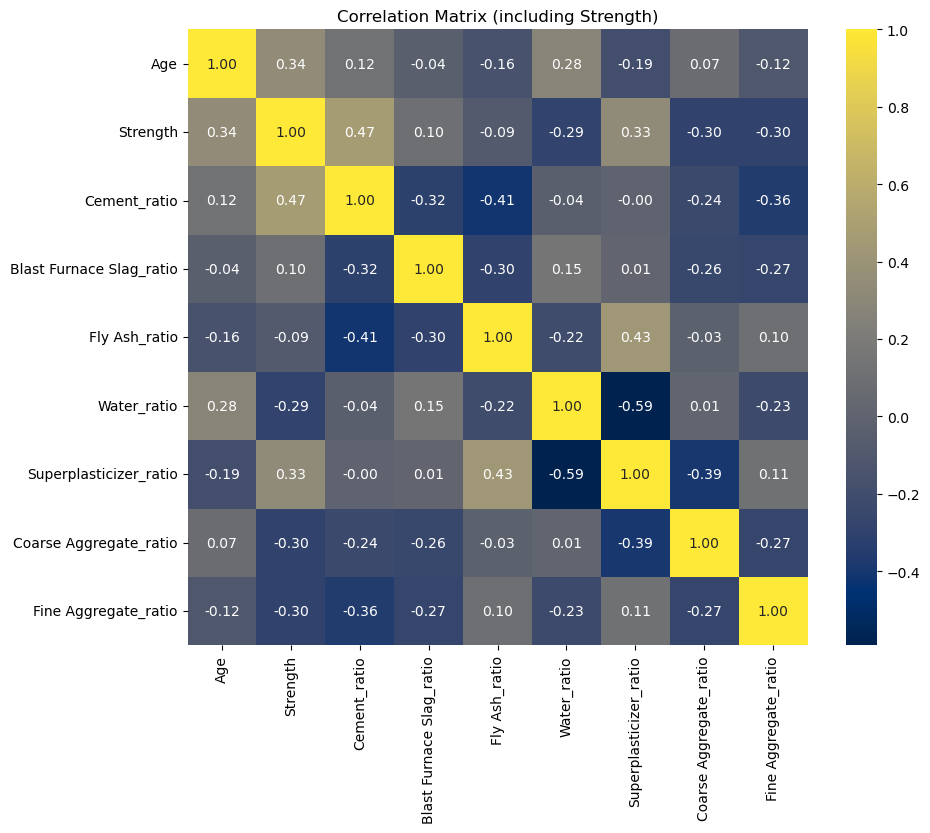

In [6]:
#concrete_data["Cment_water_ratio"] = concrete_data["Cement"] / concrete_data["Water"]
#concrete_data["Cement_to_Coarse_Aggregate_ratio"] = concrete_data["Cement"] / concrete_data["Coarse Aggregate"]
#concrete_data["Cement_to_Fine_Aggregate_ratio"] = concrete_data["Cement"] / concrete_data["Fine Aggregate"]
import seaborn as sns

columns_to_remove = ["Total", "Age_cat"]
concrete_data = concrete_data.drop(columns=columns_to_remove, axis=1, errors="ignore")

corr_matrix = concrete_data.corr()
corr_matrix ["Strength"].sort_values(ascending = False)

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='cividis', fmt=".2f")
plt.title('Correlation Matrix (including Strength)')
plt.show()


# Har fiklet litt med denne. Random forrest gir meg best resultat, men har kode for polynom, svr og desicion tree i et annet dokument. Denne gir litt feil pga jeg fiklet med test og treningsettet over

In [7]:

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import PolynomialFeatures
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.inspection import permutation_importance
from sklearn.linear_model import Ridge
from sklearn.model_selection import RandomizedSearchCV


# Må fjerne kolonner-----------------------------------------------------------------------------------------------------------------------

columns_to_remove = ["Strength", "Age_cat", "Total"]
scaler = StandardScaler()
# Sepererer fetures x fra labels y for trening
x_train_scaled = scaler.fit_transform(strat_train_set.drop(columns_to_remove, axis=1))
y_train = strat_train_set["Strength"]

# Sepererer fetures x fra labels y for test
x_test_scaled = scaler.transform(strat_test_set.drop(columns_to_remove, axis=1))
y_test = strat_test_set["Strength"]

x_train = pd.DataFrame(x_train_scaled, columns=strat_train_set.drop(columns_to_remove, axis=1).columns)
x_test = pd.DataFrame(x_test_scaled, columns=strat_test_set.drop(columns_to_remove, axis=1).columns)


ML_model =  Pipeline([       #Gjør klar Machine Learning modellen
    ('regressor', RandomForestRegressor(n_estimators=100, 
                                        max_depth=5,  
                                        min_samples_split=30,
                                        min_samples_leaf=15,
                                        max_features="sqrt",
                                        max_samples=0.7,  
                                        bootstrap=True,  
                                        min_impurity_decrease=0.05,  
                                        random_state=42))
    #('regressor', DecisionTreeRegressor(max_depth=20, min_samples_split=5))  
])

param_grid = {
    'regressor__n_estimators': [50, 100],  # Fewer trees reduce complexity
    'regressor__max_depth': [3, 5],  # Very shallow trees prevent memorization
    'regressor__min_samples_split': [20, 30, 50],  # Requires more samples per split
    'regressor__min_samples_leaf': [10, 15, 20],  # Makes trees more generalized
    'regressor__max_features': ['sqrt', 'log2'],  # Limits feature selection per tree
    'regressor__max_samples': [0.5, 0.7],  # Uses subsets of training data for randomness
    'regressor__min_impurity_decrease': [0.01, 0.05]  # Only splits on significant improvements
}

grid_search = GridSearchCV(ML_model, param_grid, cv=10, scoring='neg_mean_squared_error', n_jobs=-1)

grid_search.fit(x_train, y_train)


best_rf_model = grid_search.best_estimator_
best_params = grid_search.best_params_

print("Best Hyperparameters:", best_params)


#ML_model.fit(x_train, y_train) #Setter inn training settet til den tidligere definerte maskin leringsmodellen '

feature_importances = pd.Series(best_rf_model["regressor"].feature_importances_, index=x_train.columns)

# Sort and display
print(feature_importances.sort_values(ascending=False))


#----------------------------------------------------------------------------------------------------------
best_params_cleaned = {k.replace("regressor__", ""): v for k, v in best_params.items()}
best_rf = RandomForestRegressor(**best_params_cleaned, random_state=42)

scores = cross_val_score(best_rf, x_train, y_train, 
                         scoring="neg_mean_squared_error", cv=10)  #Cross valideringsfunksjon øker presisjon og reduserer Overfitting, folds = cv = 10
Forest_rmse_scores = np.sqrt(-scores)
#----------------------------------------------------------------------------------------------------------



def display_scores(scores):     
    print("Scores:", scores)     
    print("Mean:", scores.mean())
    print("Standard deviation:", scores.std())

display_scores(Forest_rmse_scores) 


y_pred = best_rf_model.predict(x_test)

final_rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("Final Test RMSE:", final_rmse)

Best Hyperparameters: {'regressor__max_depth': 5, 'regressor__max_features': 'log2', 'regressor__max_samples': 0.7, 'regressor__min_impurity_decrease': 0.01, 'regressor__min_samples_leaf': 10, 'regressor__min_samples_split': 20, 'regressor__n_estimators': 100}
Age                         0.365852
Cement_ratio                0.224390
Water_ratio                 0.154400
Superplasticizer_ratio      0.067852
Coarse Aggregate_ratio      0.067685
Fine Aggregate_ratio        0.064448
Blast Furnace Slag_ratio    0.031855
Fly Ash_ratio               0.023517
dtype: float64
Scores: [8.26814229 5.97719195 8.20722226 8.77314836 6.94272132 7.02886251
 9.13660765 7.65659006 7.54937432 6.94007747]
Mean: 7.647993818886713
Standard deviation: 0.9144682322057309
Final Test RMSE: 8.533178292345694


Feature Overlap in Train & Test: Index(['Age', 'Cement_ratio', 'Blast Furnace Slag_ratio', 'Fly Ash_ratio',
       'Water_ratio', 'Superplasticizer_ratio', 'Coarse Aggregate_ratio',
       'Fine Aggregate_ratio'],
      dtype='object')


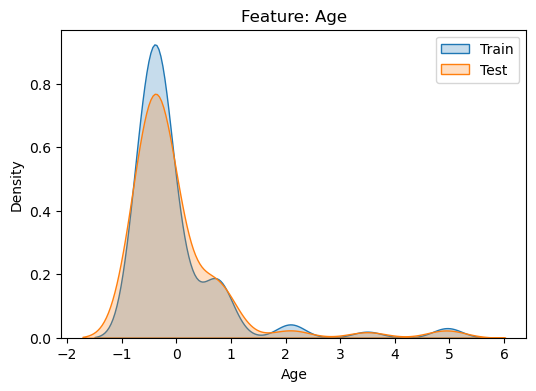

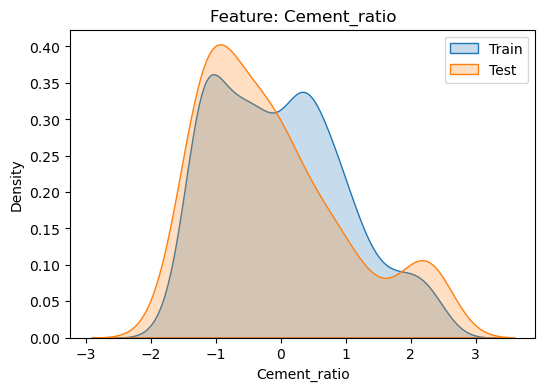

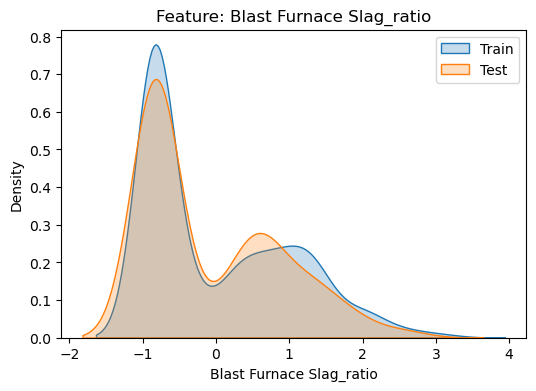

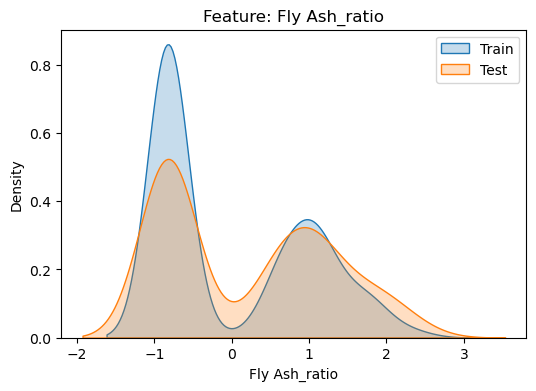

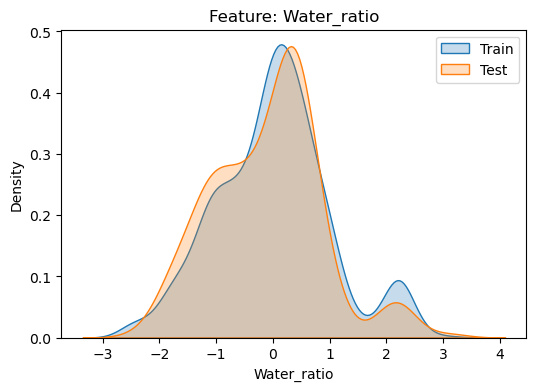

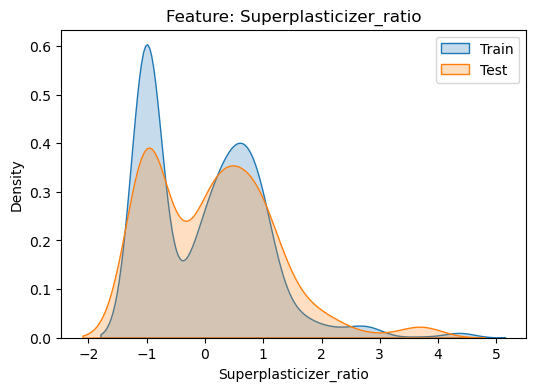

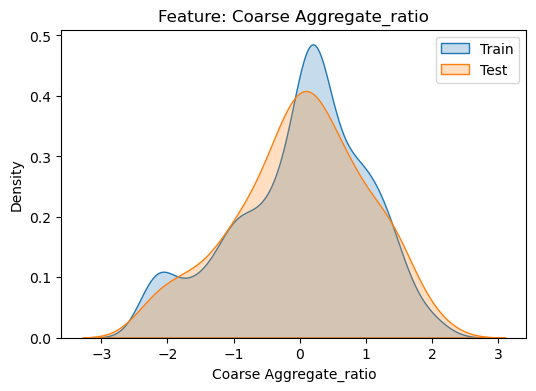

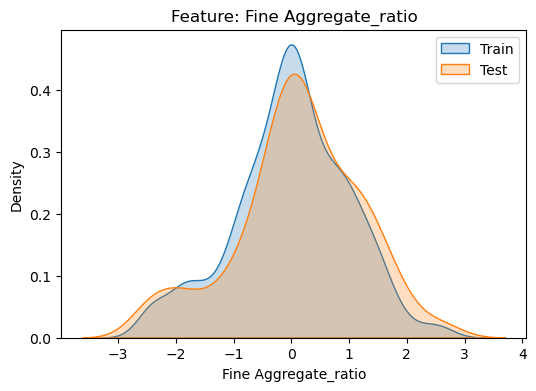

In [8]:
print("Feature Overlap in Train & Test:", x_train.columns.intersection(x_test.columns))

import matplotlib.pyplot as plt
import seaborn as sns

# Plot feature distributions
for col in x_train.columns:
    plt.figure(figsize=(6, 4))
    sns.kdeplot(x_train[col], label="Train", shade=True)
    sns.kdeplot(x_test[col], label="Test", shade=True)
    plt.title(f"Feature: {col}")
    plt.legend()
    plt.show()


In [9]:
best_rf_model.fit(x_train, y_train)

# Cross-validation (detects overfitting)
cv_scores = cross_val_score(best_rf_model, x_train, y_train, scoring="neg_mean_squared_error", cv=5)
cv_rmse = np.sqrt(-cv_scores)
print(f"Cross-validation RMSE: {cv_rmse.mean():.3f} ± {cv_rmse.std():.3f}")

# Final test set performance
y_pred = best_rf_model.predict(x_test)
final_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"Final Test RMSE: {final_rmse:.3f}")

# Compare train vs. test performance
train_rmse = np.sqrt(mean_squared_error(y_train, best_rf_model.predict(x_train)))
print(f"Train RMSE: {train_rmse:.3f}")

Cross-validation RMSE: 7.839 ± 0.661
Final Test RMSE: 8.533
Train RMSE: 6.903


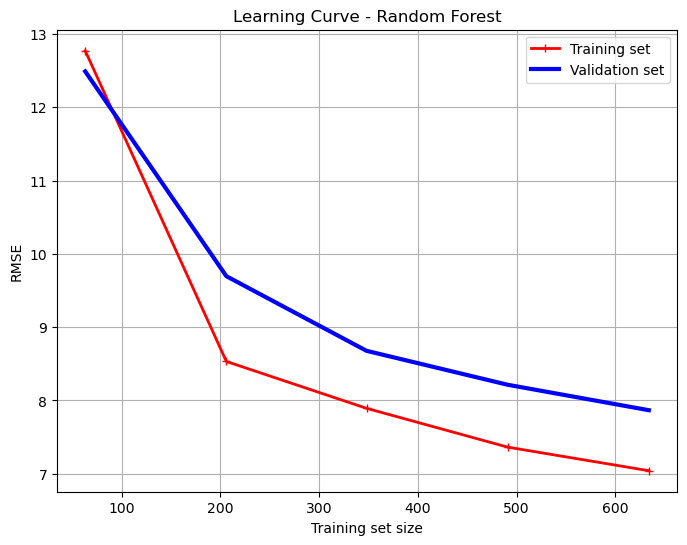

In [10]:
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt

def plot_learning_curves(model, X, y):
    train_sizes, train_scores, val_scores = learning_curve(model, X, y, cv=5, scoring="neg_mean_squared_error")

    # Convert negative MSE to RMSE
    train_rmse = np.sqrt(-train_scores.mean(axis=1))
    val_rmse = np.sqrt(-val_scores.mean(axis=1))

    plt.figure(figsize=(8, 6))
    plt.plot(train_sizes, train_rmse, "r-+", linewidth=2, label="Training set")
    plt.plot(train_sizes, val_rmse, "b-", linewidth=3, label="Validation set")
    plt.xlabel("Training set size")
    plt.ylabel("RMSE")
    plt.legend()
    plt.title("Learning Curve - Random Forest")
    plt.grid(True)
    plt.show()

# Plot learning curve
plot_learning_curves(best_rf_model, x_train, y_train)